In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
team_stats=pd.read_csv("../DATA/team_stats.csv")

### SELECCION DE EQUIPOS

In [3]:
equip_no_rep=team_stats[team_stats['slug']
                     .isin([
                            'eng.burnley',
                            'eng.nottm_forest',
                            'eng.sheff_utd',
                            'eng.luton',
                            'fra.clermont_foot',
                            'esp.cadiz',
                            'esp.almeria',
                            'esp.granada_cf',
                            'ger.vfl_bochum',
                            'ger.1_fc_kln'
 ])]

In [4]:
equip_no_rep['slug'].value_counts()

slug
eng.luton            75
eng.sheff_utd        72
esp.almeria          68
eng.burnley          67
eng.nottm_forest     66
esp.cadiz            64
esp.granada_cf       64
ger.vfl_bochum       54
ger.1_fc_kln         53
fra.clermont_foot    51
Name: count, dtype: int64

In [5]:
equip_no_rep.to_csv("../DATA/equip_no_rep.csv",index=False)

### ANÁLISIS DE VALORES ATÍPICOS

In [6]:
equip_no_rep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, 19346 to 102856
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   teamId              634 non-null    int64  
 1   abbreviation        634 non-null    object 
 2   displayName         634 non-null    object 
 3   slug                634 non-null    object 
 4   seasonType          634 non-null    int64  
 5   eventId             634 non-null    int64  
 6   teamOrder           634 non-null    int64  
 7   possessionPct       609 non-null    float64
 8   foulsCommitted      609 non-null    float64
 9   yellowCards         609 non-null    float64
 10  redCards            609 non-null    float64
 11  offsides            609 non-null    float64
 12  wonCorners          609 non-null    float64
 13  saves               609 non-null    float64
 14  totalShots          609 non-null    float64
 15  shotsOnTarget       609 non-null    float64
 16  shotPc

In [7]:
columns=['possessionPct',
       'foulsCommitted', 'yellowCards', 'redCards', 'offsides', 'wonCorners',
       'saves', 'totalShots', 'shotsOnTarget', 'shotPct', 'penaltyKickGoals',
       'penaltyKickShots', 'accuratePasses', 'totalPasses', 'passPct',
       'accurateCrosses', 'totalCrosses', 'crossPct', 'totalLongBalls',
       'accurateLongBalls', 'longballPct', 'blockedShots', 'effectiveTackles',
       'totalTackles', 'tacklePct', 'interceptions', 'effectiveClearance',
       'totalClearance']

In [8]:
summary_data = []

for col in columns:
    total_records = len(equip_no_rep[col])
    zero_count = (equip_no_rep[col] == 0).sum()
    nan_count = equip_no_rep[col].isna().sum()

    summary_data.append({
        'Column': col,
        'Total_Records': total_records,
        'Zero_Count': zero_count,
        'NaN_Count': nan_count,
        'Zero_or_NaN_Count': zero_count + nan_count
    })

summary_df = pd.DataFrame(summary_data)

In [11]:
summary_df

,Column,Total_Records,Zero_Count,NaN_Count,Zero_or_NaN_Count
0,possessionPct,634,1,25,26
1,foulsCommitted,634,3,25,28
2,yellowCards,634,71,25,96
3,redCards,634,555,25,580
4,offsides,634,360,25,385
5,wonCorners,634,17,25,42
6,saves,634,45,25,70
7,totalShots,634,1,25,26
8,shotsOnTarget,634,17,25,42
9,shotPct,634,18,25,43


In [9]:
cols_to_replace = [
    'possessionPct', 'foulsCommitted', 'accuratePasses', 'totalPasses', 'passPct',
    'totalLongBalls', 'accurateLongBalls', 'longballPct', 'effectiveTackles',
    'tacklePct', 'interceptions', 'effectiveClearance', 'totalClearance'
]

equip_no_rep = equip_no_rep.astype({col: 'float64' for col in cols_to_replace})

equip_no_rep = equip_no_rep.assign(
    **{
        col: equip_no_rep.groupby('slug')[col].transform(
            lambda x: x.where(x != 0, x[x != 0].mean())
        )
        for col in cols_to_replace
    }
)

In [10]:
summary_data_outliers = []

for col in columns:
    total_records = len(equip_no_rep[col])
    zero_count = (equip_no_rep[col] == 0).sum()
    nan_count = equip_no_rep[col].isna().sum()

    summary_data_outliers.append({
        'Column': col,
        'Total_Records': total_records,
        'Zero_Count': zero_count,
        'NaN_Count': nan_count,
        'Zero_or_NaN_Count': zero_count + nan_count
    })

summary_df_outliers = pd.DataFrame(summary_data_outliers)


In [14]:
summary_df_outliers

,Column,Total_Records,Zero_Count,NaN_Count,Zero_or_NaN_Count
0,possessionPct,634,0,25,25
1,foulsCommitted,634,0,25,25
2,yellowCards,634,71,25,96
3,redCards,634,555,25,580
4,offsides,634,360,25,385
5,wonCorners,634,17,25,42
6,saves,634,45,25,70
7,totalShots,634,1,25,26
8,shotsOnTarget,634,17,25,42
9,shotPct,634,18,25,43


In [11]:
equip_no_rep_clean=equip_no_rep.dropna()

In [12]:
summary_data_clean = []

for col in columns:
    total_records = len(equip_no_rep[col])
    zero_count = (equip_no_rep_clean[col] == 0).sum()
    nan_count = equip_no_rep_clean[col].isna().sum()

    summary_data_clean.append({
        'Column': col,
        'Total_Records': total_records,
        'Zero_Count': zero_count,
        'NaN_Count': nan_count,
        'Zero_or_NaN_Count': zero_count + nan_count
    })

summary_df_clean = pd.DataFrame(summary_data_clean)

summary_df_clean

,Column,Total_Records,Zero_Count,NaN_Count,Zero_or_NaN_Count
0,possessionPct,634,0,0,0
1,foulsCommitted,634,0,0,0
2,yellowCards,634,71,0,71
3,redCards,634,555,0,555
4,offsides,634,360,0,360
5,wonCorners,634,17,0,17
6,saves,634,45,0,45
7,totalShots,634,1,0,1
8,shotsOnTarget,634,17,0,17
9,shotPct,634,18,0,18


In [13]:
equip_no_rep_clean["slug"].value_counts()

slug
eng.sheff_utd        71
eng.luton            67
esp.almeria          66
eng.burnley          65
eng.nottm_forest     64
esp.granada_cf       62
esp.cadiz            61
ger.1_fc_kln         51
ger.vfl_bochum       51
fra.clermont_foot    51
Name: count, dtype: int64

In [14]:
equip_no_rep_clean.to_csv("../DATA/equip_no_rep_clean.csv",index=False)

### CÁLCULO DE ESTADÍSTICAS

In [15]:
columns=['possessionPct',
       'foulsCommitted', 'yellowCards', 'redCards', 'offsides', 'wonCorners',
       'saves', 'totalShots', 'shotsOnTarget', 'shotPct', 'penaltyKickGoals',
       'penaltyKickShots', 'accuratePasses', 'totalPasses', 'passPct',
       'accurateCrosses', 'totalCrosses', 'crossPct', 'totalLongBalls',
       'accurateLongBalls', 'longballPct', 'blockedShots', 'effectiveTackles',
       'totalTackles', 'tacklePct', 'interceptions', 'effectiveClearance',
       'totalClearance']

In [16]:
media = equip_no_rep_clean[columns].mean()
print(f"\nMedia:\n{media}")
varianza = equip_no_rep_clean[columns].var()
print(f"Varianza:{varianza}")
Desviacion_Estandar = equip_no_rep_clean[columns].std()
print(f"Desviacion Estandar:{Desviacion_Estandar}")
mediana = equip_no_rep_clean[columns].median()
print(f"Mediana:{mediana}")
moda = equip_no_rep_clean[columns].mode()
print(f"Moda:{moda}")
q1 = equip_no_rep_clean[columns].quantile(0.25)
q2 = equip_no_rep_clean[columns].quantile(0.50)
q3 = equip_no_rep_clean[columns].quantile(0.75)
print(f"Q1:{q1}")
print(f"Q2:{q2}")
print(f"Q3:{q3}")


Media:
possessionPct          50.040092
foulsCommitted         12.312084
yellowCards             2.119869
redCards                0.096880
offsides                0.922824
wonCorners              5.187192
saves                   2.817734
totalShots             12.732348
shotsOnTarget           4.193760
shotPct                 0.343021
penaltyKickGoals        0.105090
penaltyKickShots        0.142857
accuratePasses        299.946257
totalPasses           372.623289
passPct                 0.806422
accurateCrosses         2.182266
totalCrosses            9.284072
crossPct                0.122660
totalLongBalls         54.982063
accurateLongBalls      23.609148
longballPct             0.450445
blockedShots            3.628900
effectiveTackles        9.668593
totalTackles            8.295567
tacklePct               0.638301
interceptions           8.455954
effectiveClearance     23.963552
totalClearance         23.963552
dtype: float64
Varianza:possessionPct           115.794927
foulsComm

In [17]:
equip_no_rep_est = equip_no_rep_clean[columns].describe(include='number', percentiles=[.25, .5, .75]).T
equip_no_rep_est['variance'] = equip_no_rep_clean[columns].var()
equip_no_rep_est['std'] = equip_no_rep_clean[columns].std()
equip_no_rep_est['median'] = equip_no_rep_clean[columns].median()
equip_no_rep_est['mode'] = equip_no_rep_clean[columns].apply(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
)

equip_no_rep_est

,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,609.0,50.040092,10.760805,19.0,42.4,50.200000,57.500000,100.0,115.794927,50.200000,48.4
foulsCommitted,609.0,12.312084,3.813319,1.0,10.0,12.000000,15.000000,28.0,14.541403,12.000000,11.0
yellowCards,609.0,2.119869,1.470236,0.0,1.0,2.000000,3.000000,8.0,2.161595,2.000000,2.0
redCards,609.0,0.096880,0.327681,0.0,0.0,0.000000,0.000000,3.0,0.107375,0.000000,0.0
offsides,609.0,0.922824,1.393932,0.0,0.0,0.000000,2.000000,7.0,1.943047,0.000000,0.0
wonCorners,609.0,5.187192,3.059353,0.0,3.0,5.000000,7.000000,18.0,9.359638,5.000000,5.0
saves,609.0,2.817734,1.824887,0.0,1.0,3.000000,4.000000,9.0,3.330211,3.000000,3.0
totalShots,609.0,12.732348,5.247395,0.0,9.0,12.000000,16.000000,34.0,27.535153,12.000000,11.0
shotsOnTarget,609.0,4.193760,2.354006,0.0,3.0,4.000000,5.000000,14.0,5.541343,4.000000,3.0
shotPct,609.0,0.343021,0.161677,0.0,0.2,0.300000,0.400000,1.0,0.026140,0.300000,0.3


### MATRIZ DE CORRELACIÓN

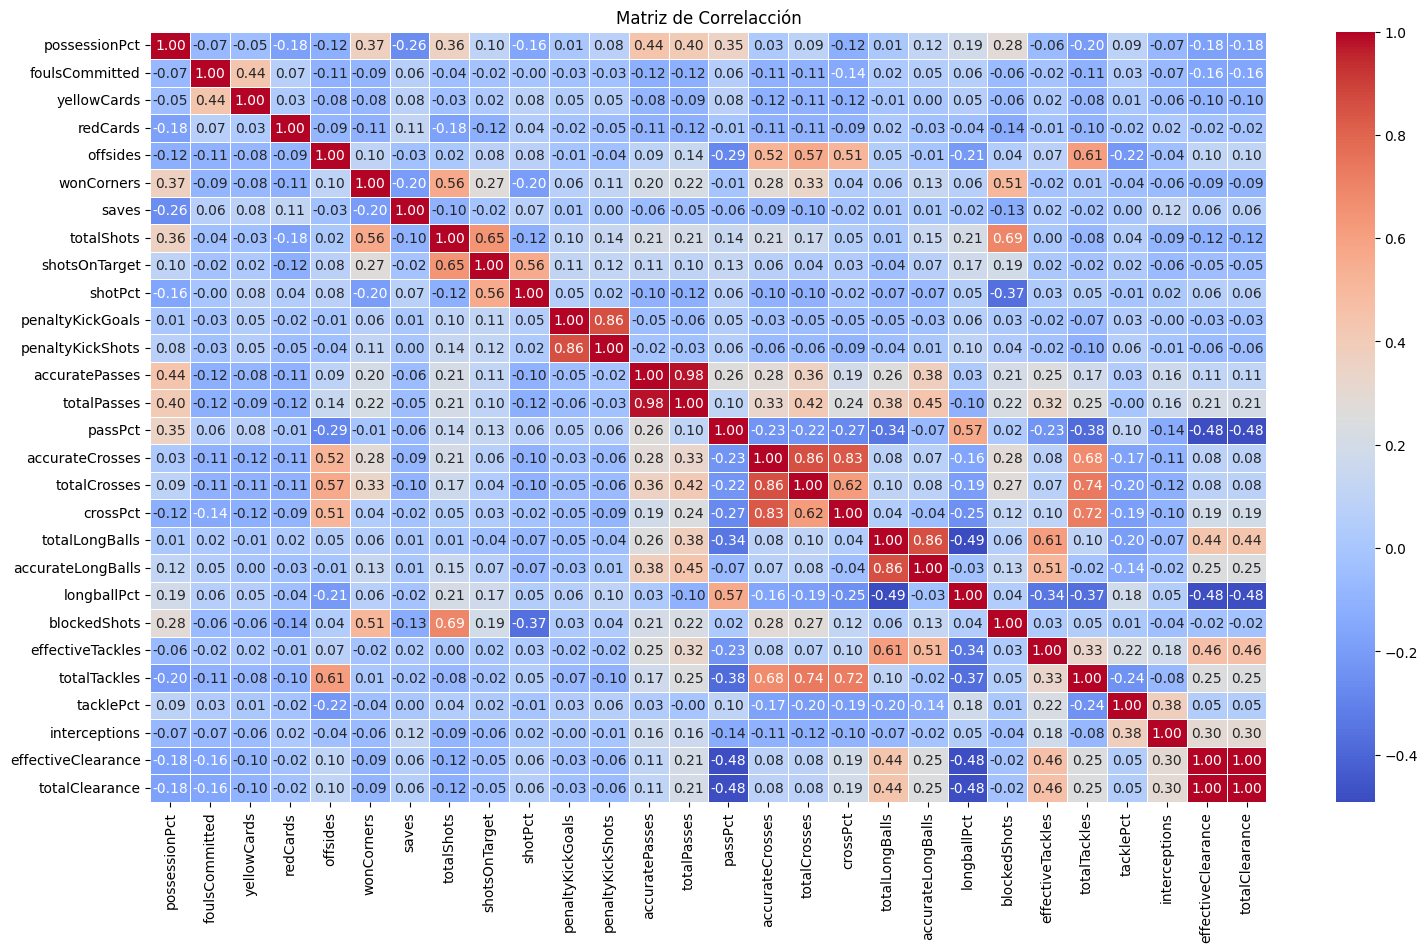

In [24]:
matriz_correlacion = equip_no_rep_clean[columns].corr()
plt.figure(figsize=(18,10))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, cbar=True)
plt.title("Matriz de Correlacción")
plt.show()

In [18]:
from IPython.display import display, HTML

teams = ['eng.burnley','eng.nottm_forest','eng.sheff_utd','eng.luton',
         'fra.clermont_foot','esp.cadiz', 'esp.almeria','esp.granada_cf',
         'ger.vfl_bochum','ger.1_fc_kln']

for team in teams:
    team_data = equip_no_rep_clean.query(f"slug == '{team}'")[columns]

    equip_no_rep_est = team_data.describe(include='number', percentiles=[.25, .5, .75]).T


    equip_no_rep_est['variance'] = team_data.var()
    equip_no_rep_est['median'] = team_data.median()
    equip_no_rep_est['mode'] = team_data.apply(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    )


    display(HTML(f"<h2>Statistics for: {team}</h2>"))
    display(equip_no_rep_est)
    display(HTML("<hr>")) 

,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,65.0,52.750769,12.141575,19.0,44.7,53.90000,61.1,74.9,147.417851,53.90000,44.2
foulsCommitted,65.0,11.230769,3.728141,4.0,9.0,11.00000,13.0,20.0,13.899038,11.00000,9.0
yellowCards,65.0,1.661538,1.290312,0.0,1.0,2.00000,3.0,5.0,1.664904,2.00000,1.0
redCards,65.0,0.076923,0.268543,0.0,0.0,0.00000,0.0,1.0,0.072115,0.00000,0.0
offsides,65.0,1.446154,1.392286,0.0,0.0,1.00000,2.0,5.0,1.938462,1.00000,0.0
wonCorners,65.0,4.692308,2.994386,0.0,3.0,4.00000,6.0,16.0,8.966346,4.00000,4.0
saves,65.0,2.446154,1.581443,0.0,1.0,2.00000,3.0,7.0,2.500962,2.00000,1.0
totalShots,65.0,11.138462,4.696664,3.0,8.0,11.00000,15.0,22.0,22.058654,11.00000,11.0
shotsOnTarget,65.0,3.784615,2.287823,0.0,2.0,4.00000,5.0,10.0,5.234135,4.00000,4.0
shotPct,65.0,0.338462,0.173828,0.0,0.2,0.30000,0.4,0.8,0.030216,0.30000,0.4


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,64.0,45.415873,10.634344,25.5,36.125,45.257937,51.825,77.2,113.089272,45.257937,29.6
foulsCommitted,64.0,11.269841,3.193278,4.0,9.750,11.000000,13.000,23.0,10.197027,11.000000,11.0
yellowCards,64.0,2.093750,1.519385,0.0,1.000,2.000000,3.000,8.0,2.308532,2.000000,1.0
redCards,64.0,0.031250,0.175368,0.0,0.000,0.000000,0.000,1.0,0.030754,0.000000,0.0
offsides,64.0,1.953125,1.452198,0.0,1.000,2.000000,3.000,7.0,2.108879,2.000000,2.0
wonCorners,64.0,4.843750,2.829654,0.0,3.000,4.000000,7.000,11.0,8.006944,4.000000,3.0
saves,64.0,3.046875,1.938988,0.0,1.000,3.000000,4.000,8.0,3.759673,3.000000,1.0
totalShots,64.0,12.718750,5.615932,0.0,9.000,11.500000,16.250,31.0,31.538690,11.500000,11.0
shotsOnTarget,64.0,4.375000,2.465637,0.0,3.000,4.000000,6.000,12.0,6.079365,4.000000,3.0
shotPct,64.0,0.360938,0.170543,0.0,0.300,0.300000,0.500,0.8,0.029085,0.300000,0.3


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,71.0,51.598592,10.153866,30.6,44.10,51.7,60.80,73.8,103.100998,51.7,51.7
foulsCommitted,71.0,10.873239,3.246667,4.0,8.50,11.0,13.00,20.0,10.540845,11.0,10.0
yellowCards,71.0,1.816901,1.301756,0.0,1.00,2.0,3.00,5.0,1.694567,2.0,1.0
redCards,71.0,0.028169,0.166633,0.0,0.00,0.0,0.00,1.0,0.027767,0.0,0.0
offsides,71.0,1.690141,1.358482,0.0,1.00,2.0,2.50,6.0,1.845473,2.0,1.0
wonCorners,71.0,6.197183,3.064170,0.0,4.00,6.0,8.00,14.0,9.389135,6.0,5.0
saves,71.0,2.521127,1.547894,0.0,1.00,2.0,3.00,6.0,2.395976,2.0,3.0
totalShots,71.0,13.140845,4.263787,5.0,10.00,13.0,16.00,25.0,18.179879,13.0,11.0
shotsOnTarget,71.0,4.126761,1.985156,0.0,3.00,4.0,5.00,9.0,3.940845,4.0,3.0
shotPct,71.0,0.322535,0.153248,0.0,0.20,0.3,0.40,0.9,0.023485,0.3,0.3


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,67.0,48.886567,11.442768,23.9,40.5,49.600000,56.750000,69.1,130.936938,49.600000,49.600000
foulsCommitted,67.0,12.104478,3.576583,6.0,9.0,12.000000,14.000000,22.0,12.791949,12.000000,12.000000
yellowCards,67.0,1.731343,1.052876,0.0,1.0,2.000000,2.000000,5.0,1.108548,2.000000,2.000000
redCards,67.0,0.104478,0.308188,0.0,0.0,0.000000,0.000000,1.0,0.094980,0.000000,0.000000
offsides,67.0,1.417910,1.405069,0.0,0.0,1.000000,2.000000,5.0,1.974220,1.000000,0.000000
wonCorners,67.0,6.253731,3.734943,0.0,4.0,5.000000,8.500000,18.0,13.949796,5.000000,5.000000
saves,67.0,2.597015,2.030522,0.0,1.0,2.000000,3.000000,9.0,4.123021,2.000000,3.000000
totalShots,67.0,11.835821,4.822916,3.0,8.0,11.000000,15.000000,23.0,23.260516,11.000000,8.000000
shotsOnTarget,67.0,3.626866,1.756683,1.0,2.0,3.000000,5.000000,8.0,3.085934,3.000000,3.000000
shotPct,67.0,0.329851,0.152767,0.1,0.2,0.300000,0.400000,0.8,0.023338,0.300000,0.300000


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,51.0,51.370588,1.071036e+01,33.0,43.65,52.2,58.8,73.8,1.147117e+02,52.2,48.0
foulsCommitted,51.0,11.254902,2.869447e+00,6.0,9.00,11.0,12.5,19.0,8.233725e+00,11.0,11.0
yellowCards,51.0,1.705882,1.082481e+00,0.0,1.00,2.0,2.0,4.0,1.171765e+00,2.0,2.0
redCards,51.0,0.176471,3.850134e-01,0.0,0.00,0.0,0.0,1.0,1.482353e-01,0.0,0.0
offsides,51.0,0.058824,4.200840e-01,0.0,0.00,0.0,0.0,3.0,1.764706e-01,0.0,0.0
wonCorners,51.0,4.235294,2.502704e+00,0.0,3.00,4.0,5.5,12.0,6.263529e+00,4.0,4.0
saves,51.0,3.294118,2.081289e+00,0.0,2.00,3.0,4.5,9.0,4.331765e+00,3.0,3.0
totalShots,51.0,10.196078,4.015070e+00,4.0,7.00,11.0,13.0,18.0,1.612078e+01,11.0,11.0
shotsOnTarget,51.0,3.294118,1.814322e+00,0.0,2.00,3.0,4.0,8.0,3.291765e+00,3.0,2.0
shotPct,51.0,0.335294,1.467290e-01,0.0,0.20,0.3,0.4,0.7,2.152941e-02,0.3,0.3


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,61.0,47.959016,10.065359,20.5,41.60,48.00,54.60,72.0,101.311459,48.00,35.90
foulsCommitted,61.0,14.081967,4.480681,3.0,11.00,14.00,16.00,28.0,20.076503,14.00,14.00
yellowCards,61.0,2.557377,1.638338,0.0,1.00,2.00,4.00,6.0,2.684153,2.00,2.00
redCards,61.0,0.131148,0.340363,0.0,0.00,0.00,0.00,1.0,0.115847,0.00,0.00
offsides,61.0,0.081967,0.640184,0.0,0.00,0.00,0.00,5.0,0.409836,0.00,0.00
wonCorners,61.0,4.229508,2.552080,0.0,2.00,4.00,5.00,13.0,6.513115,4.00,2.00
saves,61.0,2.688525,1.902113,0.0,1.00,3.00,4.00,7.0,3.618033,3.00,1.00
totalShots,61.0,10.885246,4.520687,2.0,8.00,10.00,14.00,24.0,20.436612,10.00,9.00
shotsOnTarget,61.0,3.704918,1.994528,0.0,2.00,3.00,5.00,9.0,3.978142,3.00,3.00
shotPct,61.0,0.354098,0.156603,0.0,0.30,0.40,0.40,0.8,0.024525,0.40,0.40


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,66.0,53.253030,9.145242,36.2,47.625000,53.500000,58.775000,79.3,83.635452,53.500000,42.300000
foulsCommitted,66.0,13.215385,3.399060,5.0,11.000000,13.000000,15.000000,23.0,11.553609,13.000000,13.000000
yellowCards,66.0,2.484848,1.561483,0.0,1.000000,2.000000,3.000000,7.0,2.438228,2.000000,2.000000
redCards,66.0,0.151515,0.503600,0.0,0.000000,0.000000,0.000000,3.0,0.253613,0.000000,0.000000
offsides,66.0,0.151515,0.898587,0.0,0.000000,0.000000,0.000000,7.0,0.807459,0.000000,0.000000
wonCorners,66.0,5.166667,3.475556,0.0,2.250000,5.000000,7.000000,17.0,12.079487,5.000000,2.000000
saves,66.0,2.909091,1.887019,0.0,2.000000,3.000000,4.000000,9.0,3.560839,3.000000,2.000000
totalShots,66.0,15.439394,5.865489,2.0,11.000000,15.000000,20.000000,31.0,34.403963,15.000000,11.000000
shotsOnTarget,66.0,5.469697,2.482057,1.0,4.000000,5.000000,7.000000,14.0,6.160606,5.000000,4.000000
shotPct,66.0,0.383333,0.155498,0.1,0.300000,0.400000,0.400000,1.0,0.024179,0.400000,0.400000


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,62.0,51.604839,9.909268e+00,36.4,45.700000,49.650000,56.725000,100.0,9.819358e+01,49.650000,38.900000
foulsCommitted,62.0,13.573770,3.712889e+00,7.0,11.000000,13.000000,16.000000,22.0,1.378554e+01,13.000000,13.000000
yellowCards,62.0,2.467742,1.554662e+00,0.0,1.000000,2.000000,3.750000,6.0,2.416975e+00,2.000000,1.000000
redCards,62.0,0.209677,4.837387e-01,0.0,0.000000,0.000000,0.000000,2.0,2.340032e-01,0.000000,0.000000
offsides,62.0,0.064516,3.996297e-01,0.0,0.000000,0.000000,0.000000,3.0,1.597039e-01,0.000000,0.000000
wonCorners,62.0,4.693548,2.446736e+00,0.0,3.000000,5.000000,6.000000,11.0,5.986515e+00,5.000000,5.000000
saves,62.0,2.967742,1.707915e+00,0.0,2.000000,3.000000,4.000000,8.0,2.916975e+00,3.000000,3.000000
totalShots,62.0,12.338710,4.669200e+00,1.0,9.000000,12.500000,15.750000,26.0,2.180143e+01,12.500000,13.000000
shotsOnTarget,62.0,4.096774,2.351907e+00,0.0,3.000000,4.000000,5.000000,11.0,5.531465e+00,4.000000,3.000000
shotPct,62.0,0.343548,1.834291e-01,0.0,0.200000,0.300000,0.400000,1.0,3.364622e-02,0.300000,0.300000


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,51.0,45.992157,10.575176,26.2,37.85,44.900000,53.550000,69.1,111.834337,44.900000,57.500000
foulsCommitted,51.0,14.000000,4.604346,1.0,11.00,14.000000,16.000000,24.0,21.200000,14.000000,15.000000
yellowCards,51.0,2.627451,1.843483,0.0,1.00,3.000000,3.500000,8.0,3.398431,3.000000,3.000000
redCards,51.0,0.039216,0.196039,0.0,0.00,0.000000,0.000000,1.0,0.038431,0.000000,0.000000
offsides,51.0,1.352941,1.683134,0.0,0.00,1.000000,2.000000,7.0,2.832941,1.000000,0.000000
wonCorners,51.0,5.529412,2.893807,0.0,3.00,6.000000,7.500000,13.0,8.374118,6.000000,2.000000
saves,51.0,3.019608,1.737702,0.0,2.00,3.000000,4.000000,7.0,3.019608,3.000000,2.000000
totalShots,51.0,13.921569,4.840839,6.0,10.50,13.000000,16.000000,28.0,23.433725,13.000000,10.000000
shotsOnTarget,51.0,4.254902,2.161880,1.0,3.00,4.000000,5.000000,10.0,4.673725,4.000000,4.000000
shotPct,51.0,0.319608,0.141449,0.1,0.20,0.300000,0.400000,0.7,0.020008,0.300000,0.200000


,count,mean,std,min,25%,50%,75%,max,variance,median,mode
possessionPct,51.0,50.880392,9.985910,21.4,44.550000,51.600000,57.750000,71.8,99.718408,51.600000,41.300000
foulsCommitted,51.0,11.823529,3.479689,6.0,9.000000,12.000000,15.000000,21.0,12.108235,12.000000,15.000000
yellowCards,51.0,2.156863,1.376554,0.0,1.000000,2.000000,3.000000,6.0,1.894902,2.000000,2.000000
redCards,51.0,0.019608,0.140028,0.0,0.000000,0.000000,0.000000,1.0,0.019608,0.000000,0.000000
offsides,51.0,0.725490,1.457099,0.0,0.000000,0.000000,1.000000,6.0,2.123137,0.000000,0.000000
wonCorners,51.0,5.823529,2.984667,0.0,3.500000,6.000000,7.000000,14.0,8.908235,6.000000,6.000000
saves,51.0,2.882353,1.762351,0.0,1.500000,3.000000,4.000000,8.0,3.105882,3.000000,3.000000
totalShots,51.0,15.921569,6.186576,5.0,11.000000,14.000000,21.000000,34.0,38.273725,14.000000,11.000000
shotsOnTarget,51.0,5.215686,3.300386,0.0,3.000000,5.000000,6.500000,14.0,10.892549,5.000000,5.000000
shotPct,51.0,0.337255,0.176591,0.0,0.200000,0.300000,0.450000,0.8,0.031184,0.300000,0.200000


In [19]:
import os
os.makedirs('../tables', exist_ok=True)
teams = ['eng.burnley','eng.nottm_forest','eng.sheff_utd','eng.luton',
         'fra.clermont_foot','esp.cadiz', 'esp.almeria','esp.granada_cf',
         'ger.vfl_bochum','ger.1_fc_kln']

team_names = {
    'eng.burnley': 'Burnley FC',
    'eng.nottm_forest': 'Nottingham Forest FC',
    'eng.sheff_utd': 'Sheffield United FC',
    'eng.luton': 'Luton Town FC',
    'fra.clermont_foot': 'Clermont Foot Auvergne',
    'esp.cadiz': 'Cádiz CF',
    'esp.almeria': 'UD Almería',
    'esp.granada_cf': 'Granada CF',
    'ger.vfl_bochum': 'VfL Bochum',
    'ger.1_fc_kln': 'F.C.Colonia'
}

for team in teams:
    team_data = equip_no_rep_clean.query(f"slug == '{team}'")[columns]

    equip_no_rep_est = team_data.describe(include='number', percentiles=[.25, .5, .75]).T.rename(columns={
        '25%': 'Q1',
        '50%': 'Q2',
        '75%': 'Q3'})
    equip_no_rep_est['variance'] = team_data.var()
    equip_no_rep_est['median'] = team_data.median()
    equip_no_rep_est['mode'] = team_data.apply(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
    )
    
    equip_no_rep_est = equip_no_rep_est[["mean","std", "Q1","Q2","Q3","variance","mode"]].round(2)
    filename = team.replace('.', '_')
    nice_name = team_names.get(team, team)
    
    filepath = f'../tables/tabla_{filename}.tex'
    
    # Generate complete table with wrapper
    with open(filepath, 'w', encoding='utf-8') as f:
        # Start table environment
        f.write('\\begin{table}[H]\n')
        f.write('\\centering\n')
        f.write(f'\\caption{{Estadísticas Descriptivas - {nice_name}}}\n')
        f.write(f'\\label{{tab:{filename}}}\n')
        f.write('\\small\n')
        
        # Column format
        num_cols = len(equip_no_rep_est.columns)
        col_format = 'l' + 'r' * num_cols
        
        # Start tabular
        f.write(f'\\begin{{tabular}}{{{col_format}}}\n')
        f.write('\\hline\n')
        
        # Header
        headers = ['Variable'] + [str(col) for col in equip_no_rep_est.columns]
        f.write(' & '.join(headers) + ' \\\\\n')
        f.write('\\hline\n')
        
        # Data rows
        for idx, row in equip_no_rep_est.iterrows():
            row_data = [str(idx)]
            for val in row:
                if pd.isna(val):
                    row_data.append('-')
                else:
                    row_data.append(f'{val:.2f}')
            f.write(' & '.join(row_data) + ' \\\\\n')
        
        f.write('\\hline\n')
        f.write('\\end{tabular}\n')
        f.write('\\end{table}\n')
    
    display(HTML(f"<h2>Statistics for: {nice_name}</h2>"))
    display(equip_no_rep_est)
    display(HTML("<hr>"))
    
    print(f"✓ Saved: {filepath}")

print(f"\n✅ All {len(teams)} complete tables saved")

,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,52.75,12.14,44.7,53.90,61.1,147.42,44.2
foulsCommitted,11.23,3.73,9.0,11.00,13.0,13.90,9.0
yellowCards,1.66,1.29,1.0,2.00,3.0,1.66,1.0
redCards,0.08,0.27,0.0,0.00,0.0,0.07,0.0
offsides,1.45,1.39,0.0,1.00,2.0,1.94,0.0
wonCorners,4.69,2.99,3.0,4.00,6.0,8.97,4.0
saves,2.45,1.58,1.0,2.00,3.0,2.50,1.0
totalShots,11.14,4.70,8.0,11.00,15.0,22.06,11.0
shotsOnTarget,3.78,2.29,2.0,4.00,5.0,5.23,4.0
shotPct,0.34,0.17,0.2,0.30,0.4,0.03,0.4


✓ Saved: ../tables/tabla_eng_burnley.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,45.42,10.63,36.12,45.26,51.82,113.09,29.6
foulsCommitted,11.27,3.19,9.75,11.00,13.00,10.20,11.0
yellowCards,2.09,1.52,1.00,2.00,3.00,2.31,1.0
redCards,0.03,0.18,0.00,0.00,0.00,0.03,0.0
offsides,1.95,1.45,1.00,2.00,3.00,2.11,2.0
wonCorners,4.84,2.83,3.00,4.00,7.00,8.01,3.0
saves,3.05,1.94,1.00,3.00,4.00,3.76,1.0
totalShots,12.72,5.62,9.00,11.50,16.25,31.54,11.0
shotsOnTarget,4.38,2.47,3.00,4.00,6.00,6.08,3.0
shotPct,0.36,0.17,0.30,0.30,0.50,0.03,0.3


✓ Saved: ../tables/tabla_eng_nottm_forest.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,51.60,10.15,44.10,51.7,60.80,103.10,51.7
foulsCommitted,10.87,3.25,8.50,11.0,13.00,10.54,10.0
yellowCards,1.82,1.30,1.00,2.0,3.00,1.69,1.0
redCards,0.03,0.17,0.00,0.0,0.00,0.03,0.0
offsides,1.69,1.36,1.00,2.0,2.50,1.85,1.0
wonCorners,6.20,3.06,4.00,6.0,8.00,9.39,5.0
saves,2.52,1.55,1.00,2.0,3.00,2.40,3.0
totalShots,13.14,4.26,10.00,13.0,16.00,18.18,11.0
shotsOnTarget,4.13,1.99,3.00,4.0,5.00,3.94,3.0
shotPct,0.32,0.15,0.20,0.3,0.40,0.02,0.3


...

✓ Saved: ../tables/tabla_esp_granada_cf.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,45.99,10.58,37.85,44.90,53.55,111.83,57.50
foulsCommitted,14.00,4.60,11.00,14.00,16.00,21.20,15.00
yellowCards,2.63,1.84,1.00,3.00,3.50,3.40,3.00
redCards,0.04,0.20,0.00,0.00,0.00,0.04,0.00
offsides,1.35,1.68,0.00,1.00,2.00,2.83,0.00
wonCorners,5.53,2.89,3.00,6.00,7.50,8.37,2.00
saves,3.02,1.74,2.00,3.00,4.00,3.02,2.00
totalShots,13.92,4.84,10.50,13.00,16.00,23.43,10.00
shotsOnTarget,4.25,2.16,3.00,4.00,5.00,4.67,4.00
shotPct,0.32,0.14,0.20,0.30,0.40,0.02,0.20


✓ Saved: ../tables/tabla_ger_vfl_bochum.tex


,mean,std,Q1,Q2,Q3,variance,mode
possessionPct,50.88,9.99,44.55,51.60,57.75,99.72,41.30
foulsCommitted,11.82,3.48,9.00,12.00,15.00,12.11,15.00
yellowCards,2.16,1.38,1.00,2.00,3.00,1.89,2.00
redCards,0.02,0.14,0.00,0.00,0.00,0.02,0.00
offsides,0.73,1.46,0.00,0.00,1.00,2.12,0.00
wonCorners,5.82,2.98,3.50,6.00,7.00,8.91,6.00
saves,2.88,1.76,1.50,3.00,4.00,3.11,3.00
totalShots,15.92,6.19,11.00,14.00,21.00,38.27,11.00
shotsOnTarget,5.22,3.30,3.00,5.00,6.50,10.89,5.00
shotPct,0.34,0.18,0.20,0.30,0.45,0.03,0.20


✓ Saved: ../tables/tabla_ger_1_fc_kln.tex

✅ All 10 complete tables saved


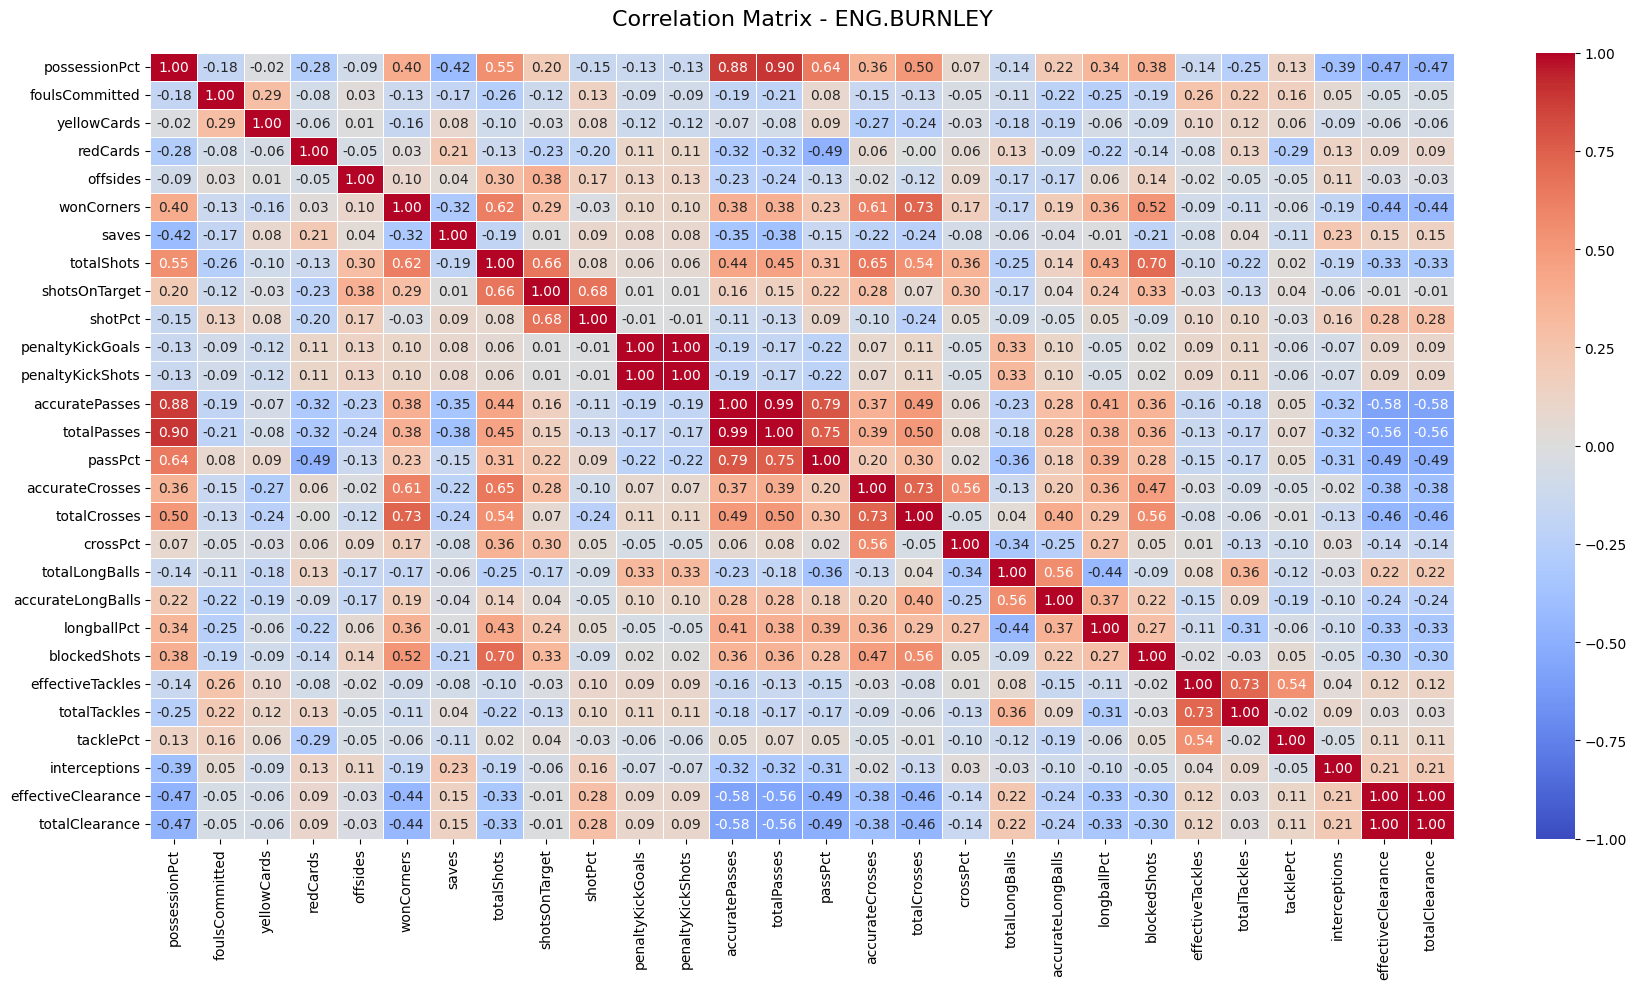

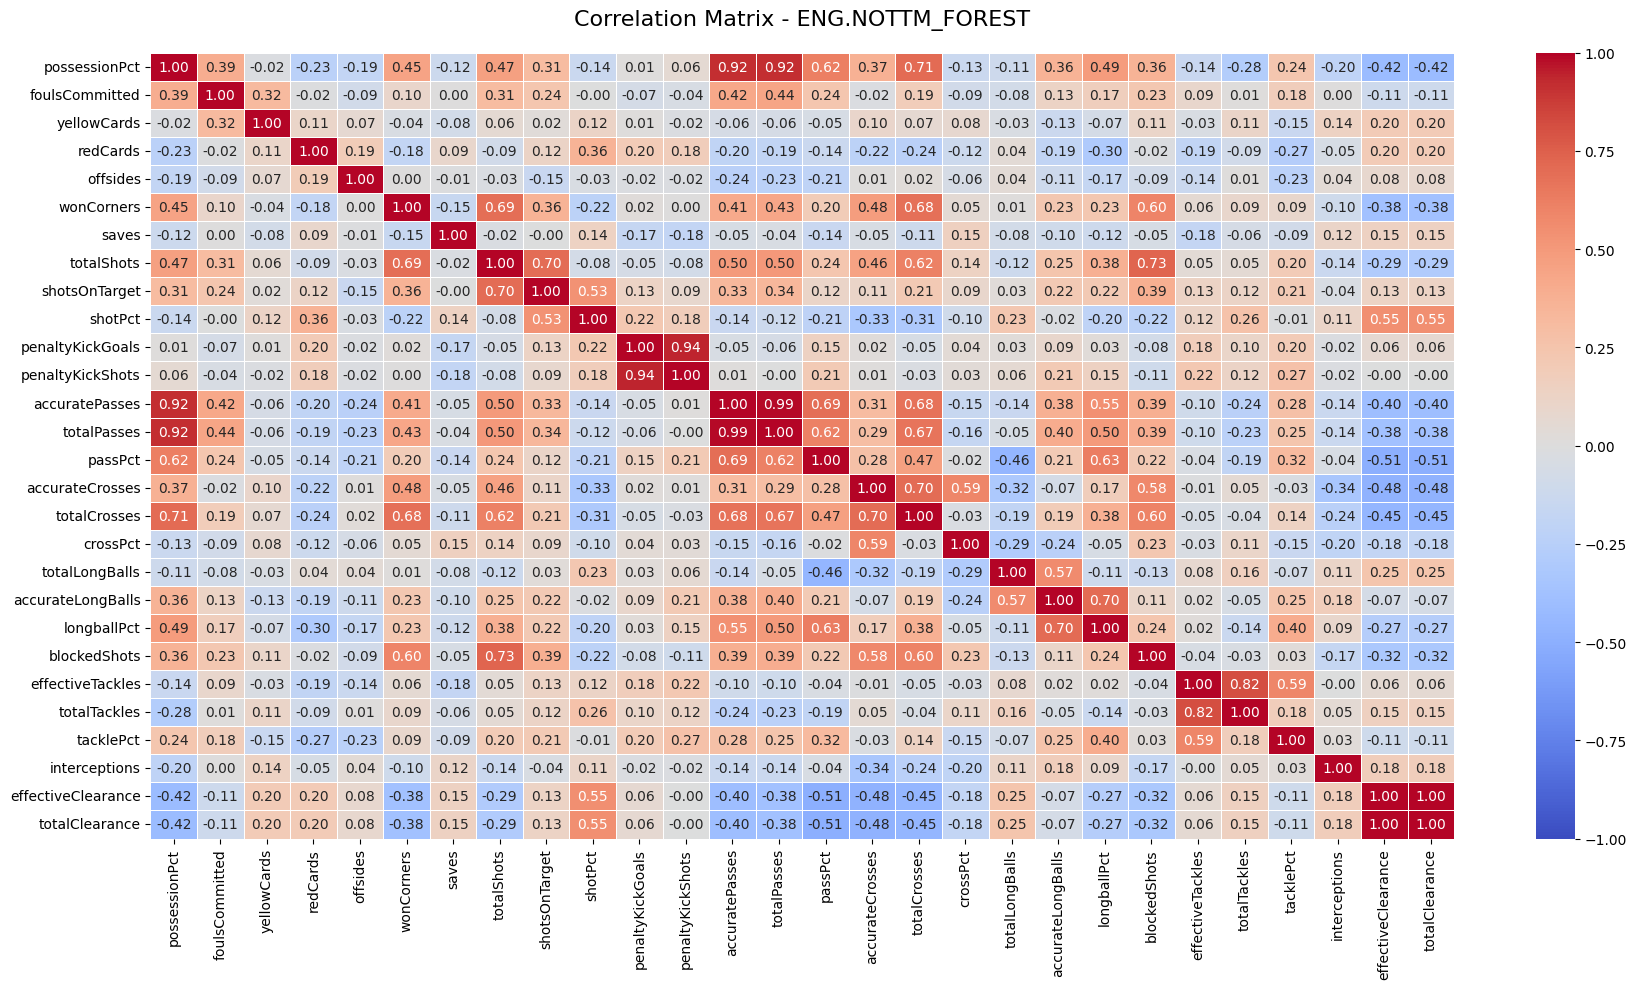

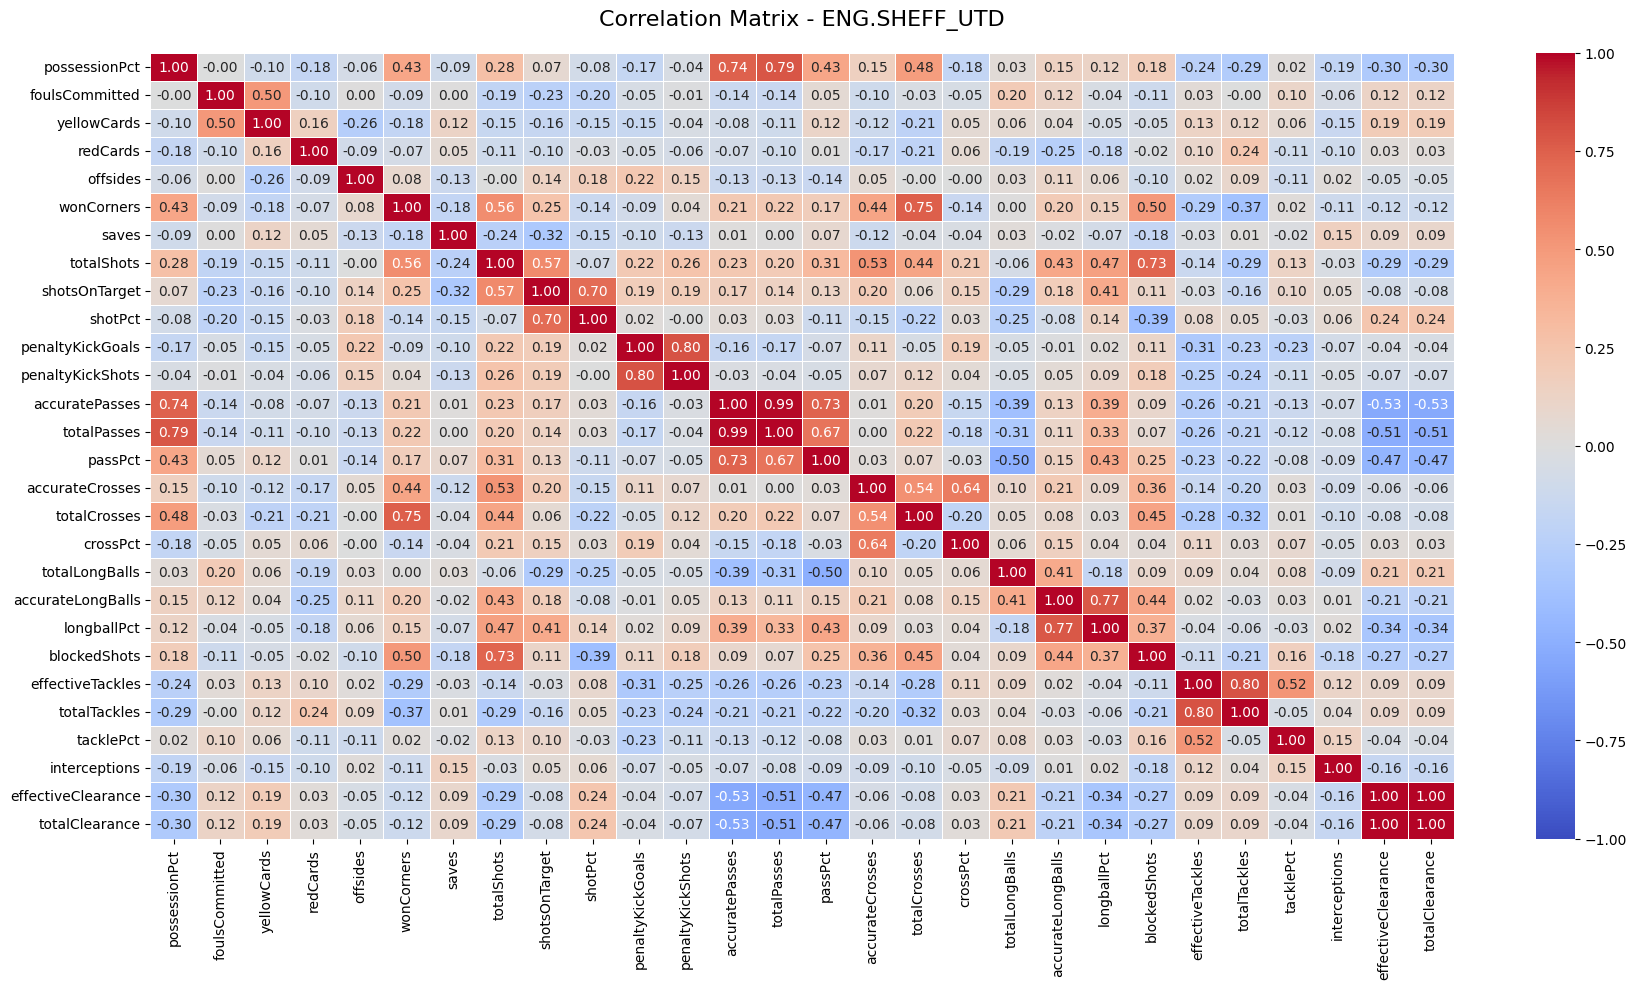

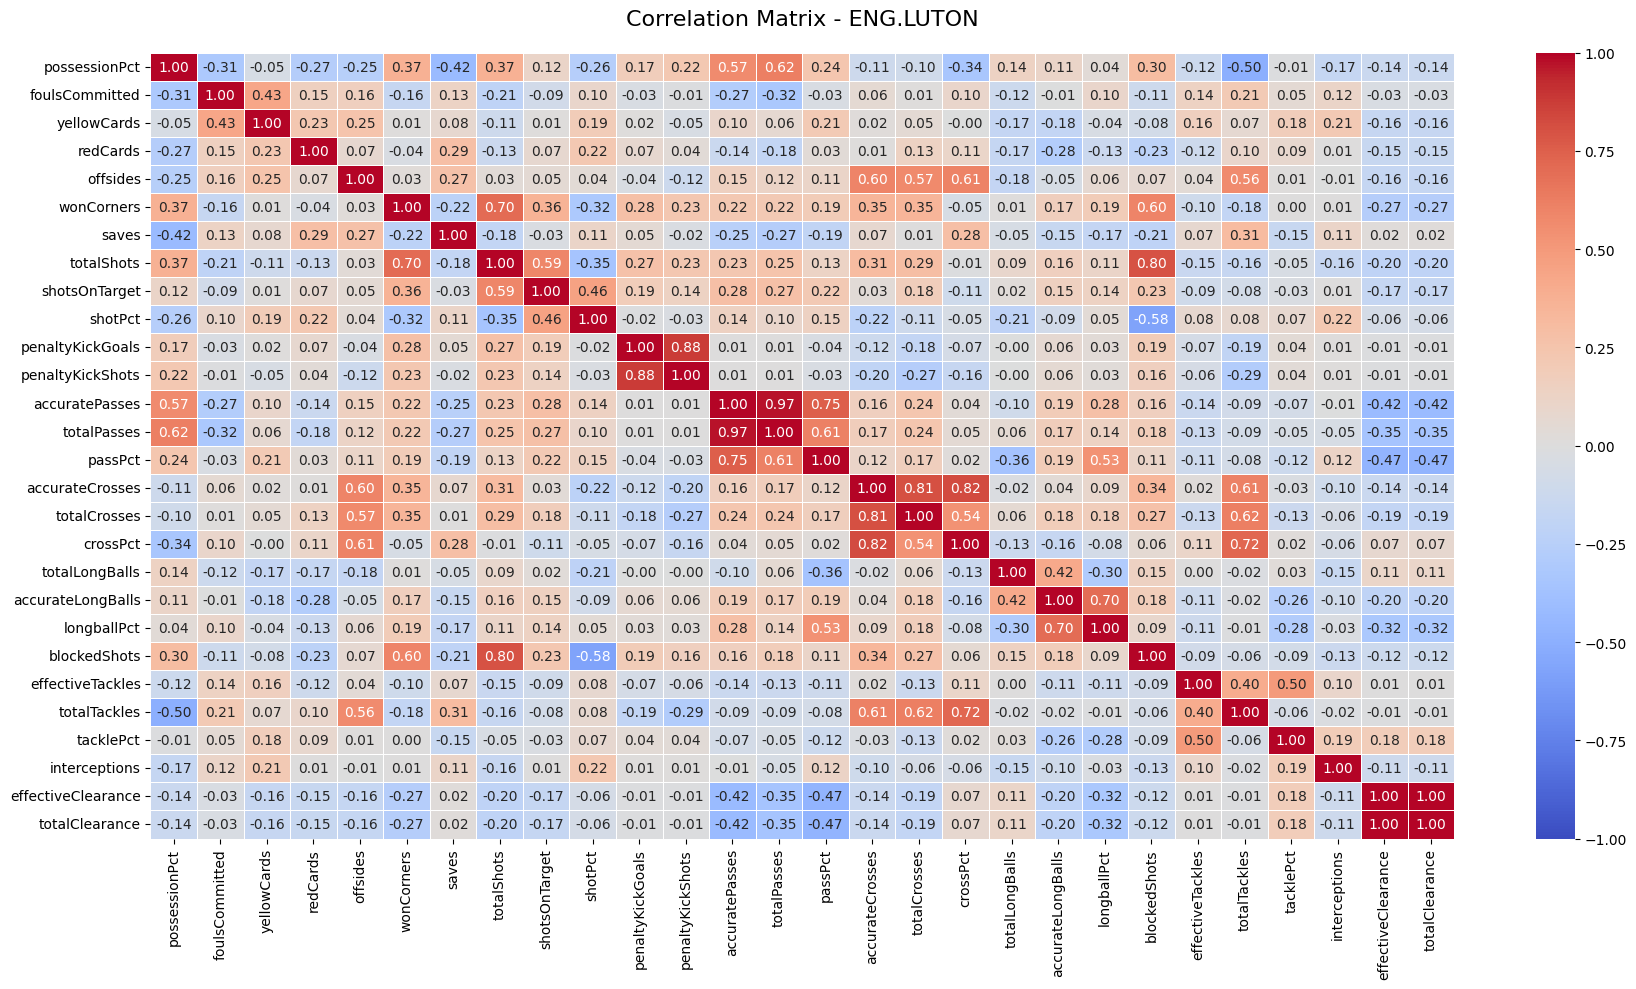

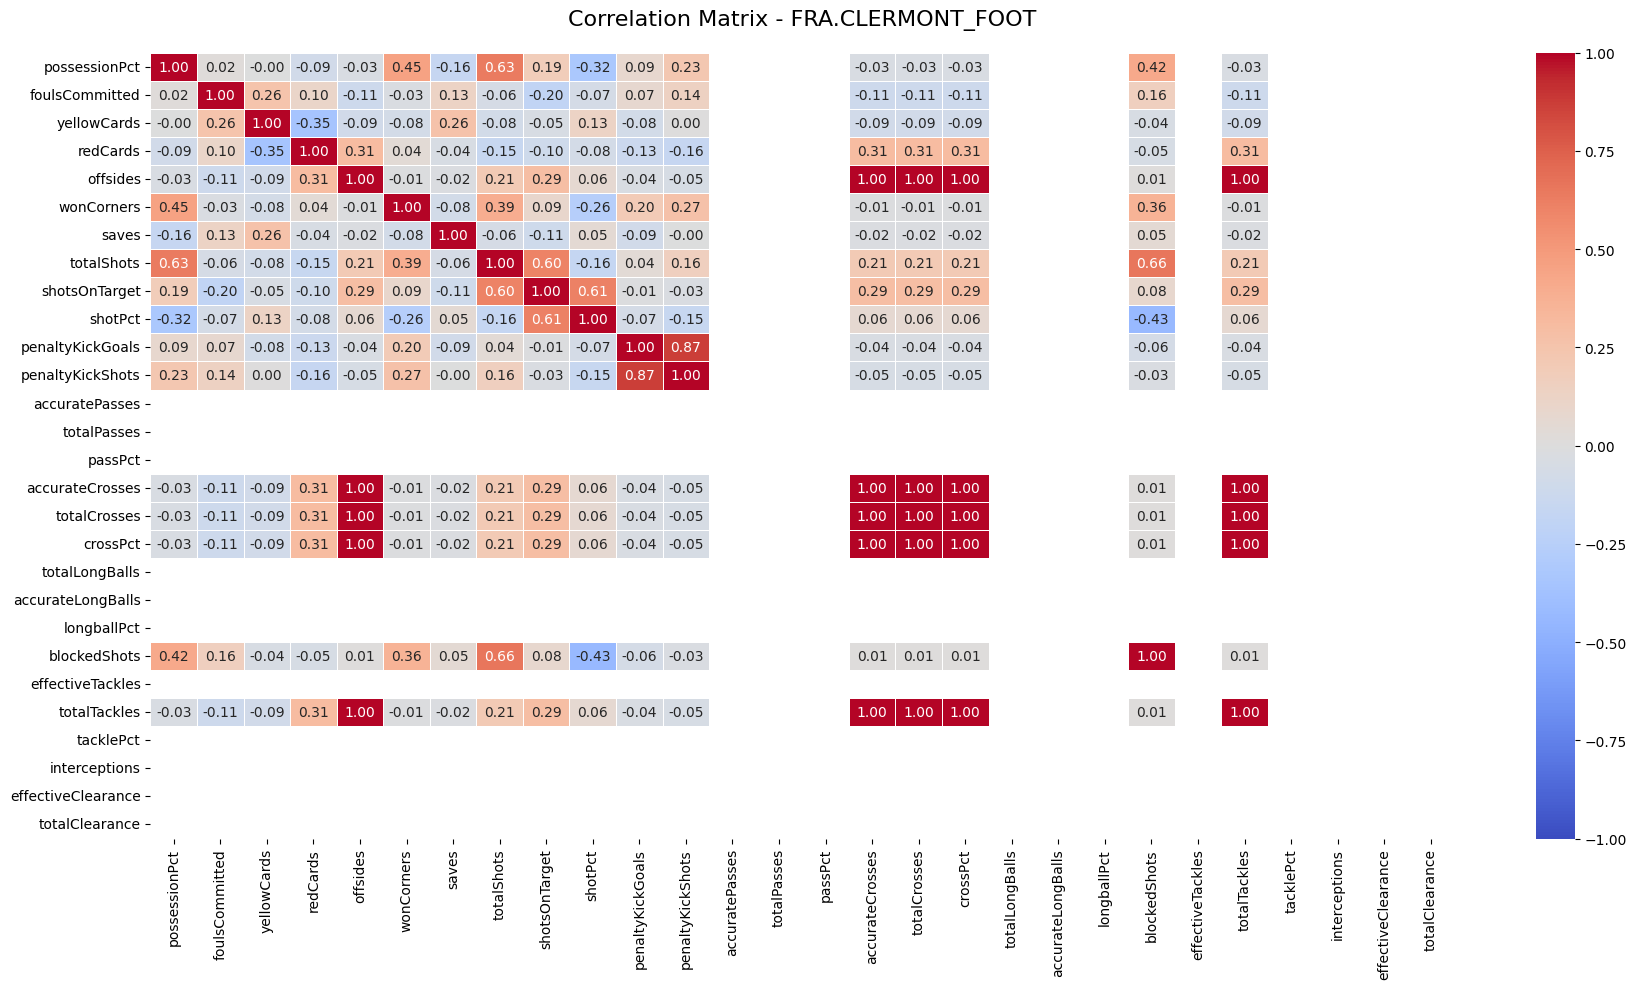

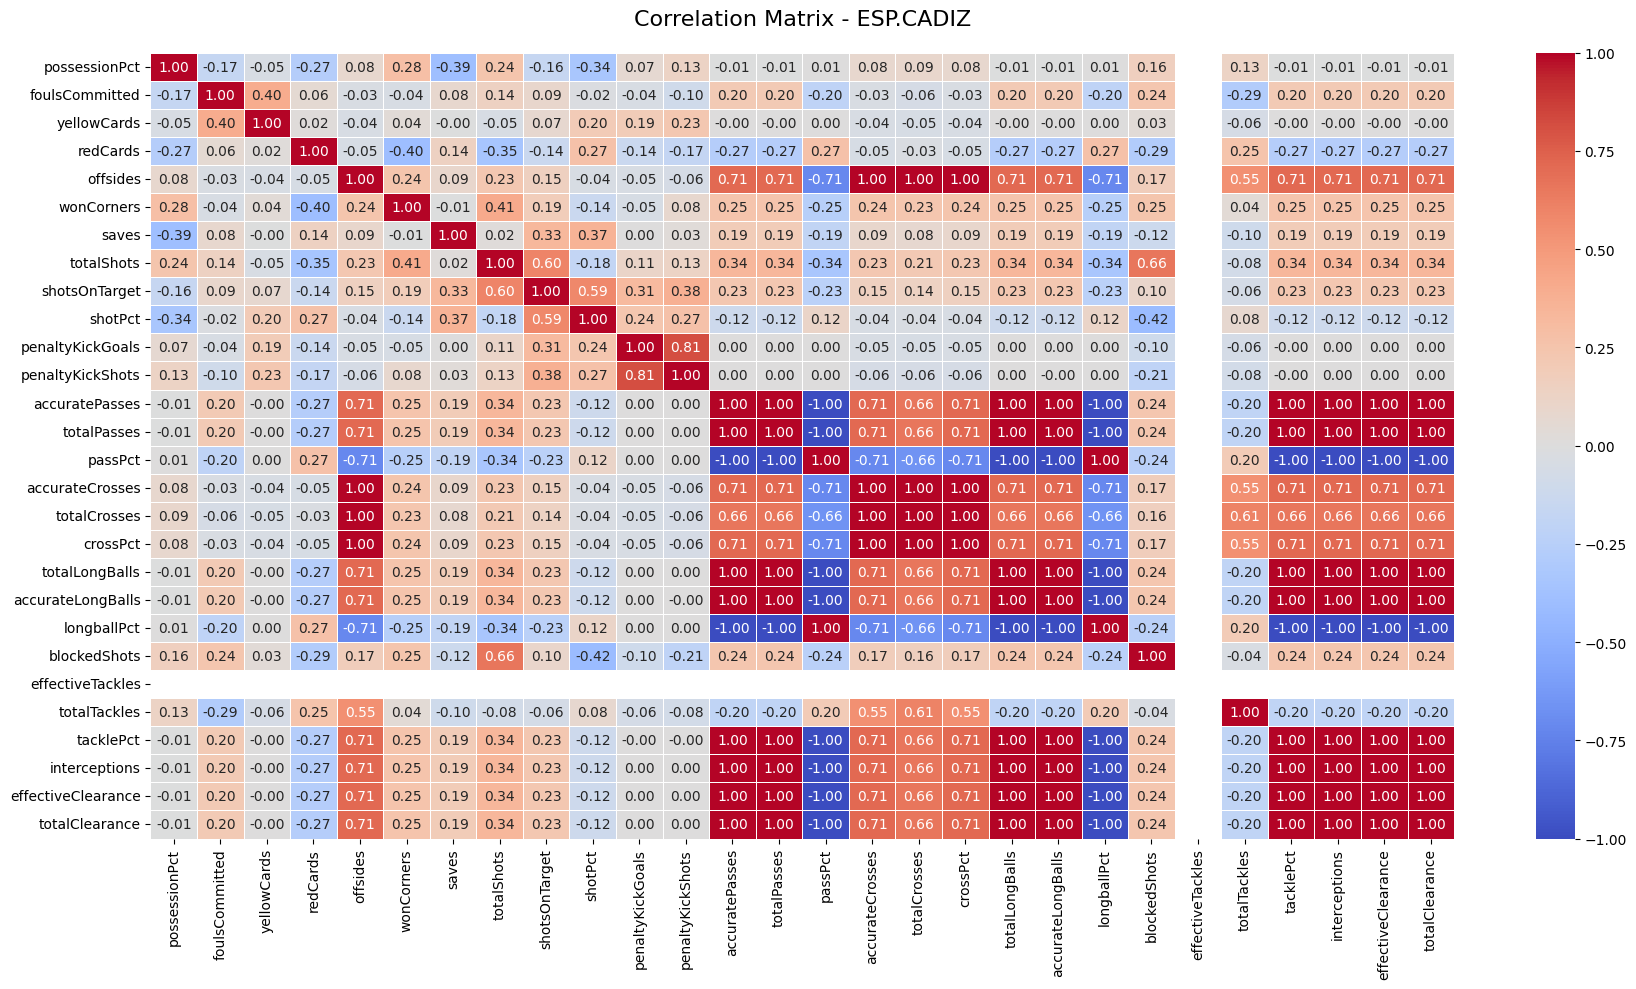

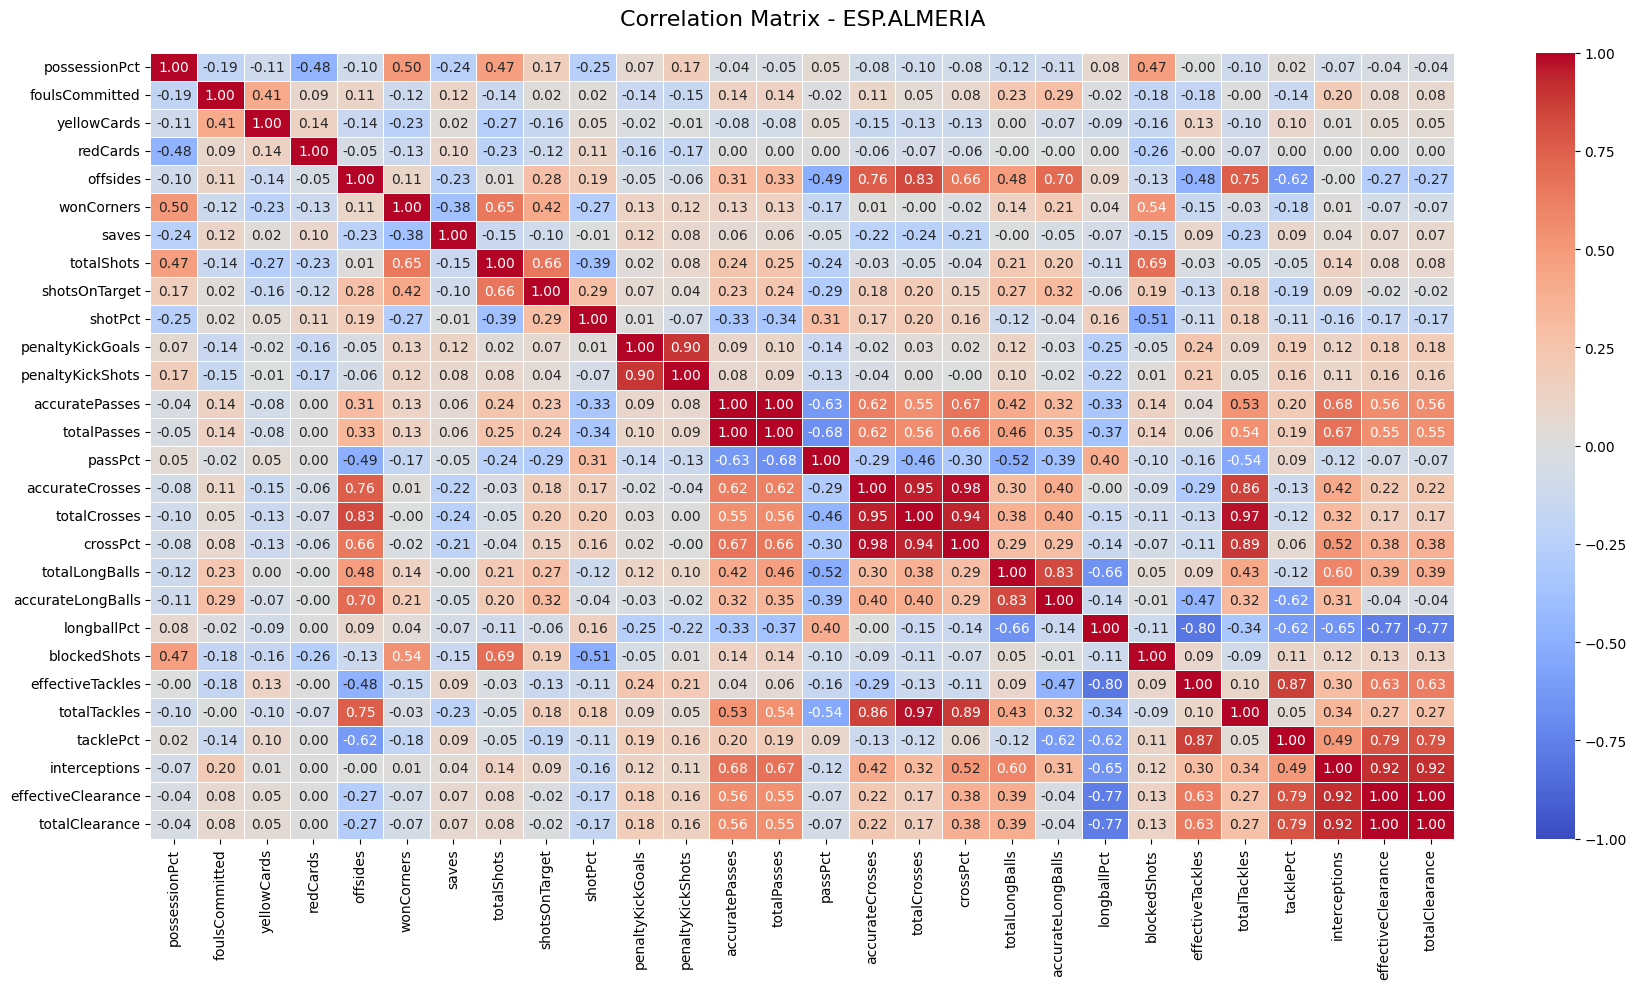

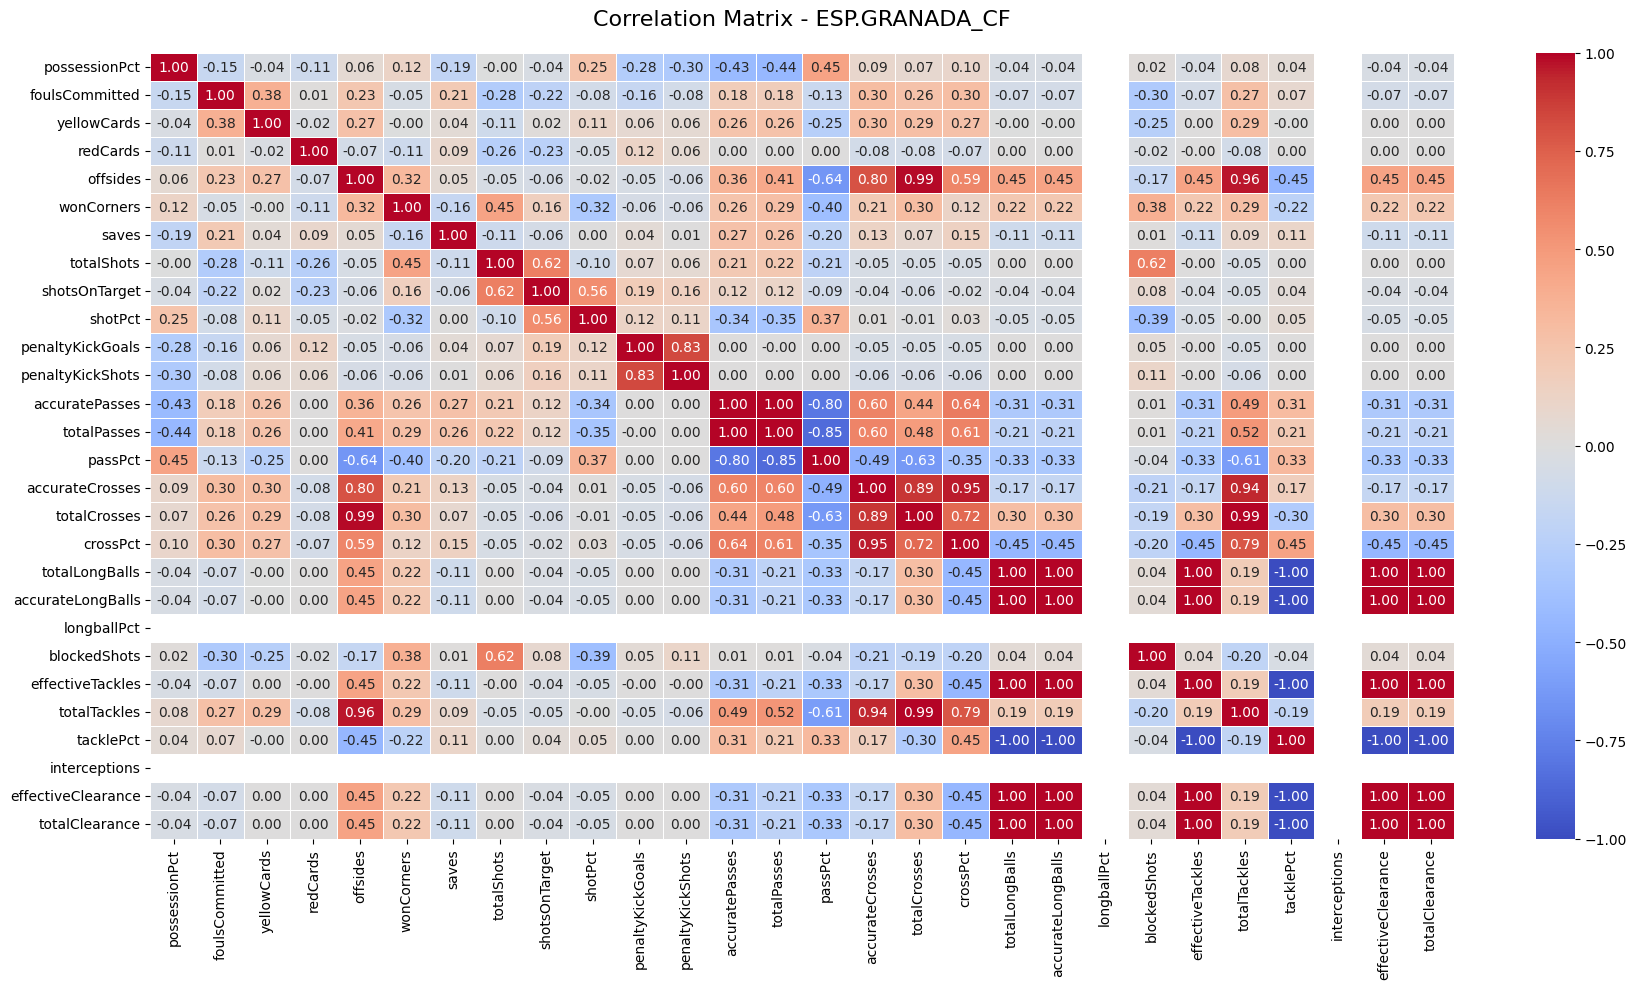

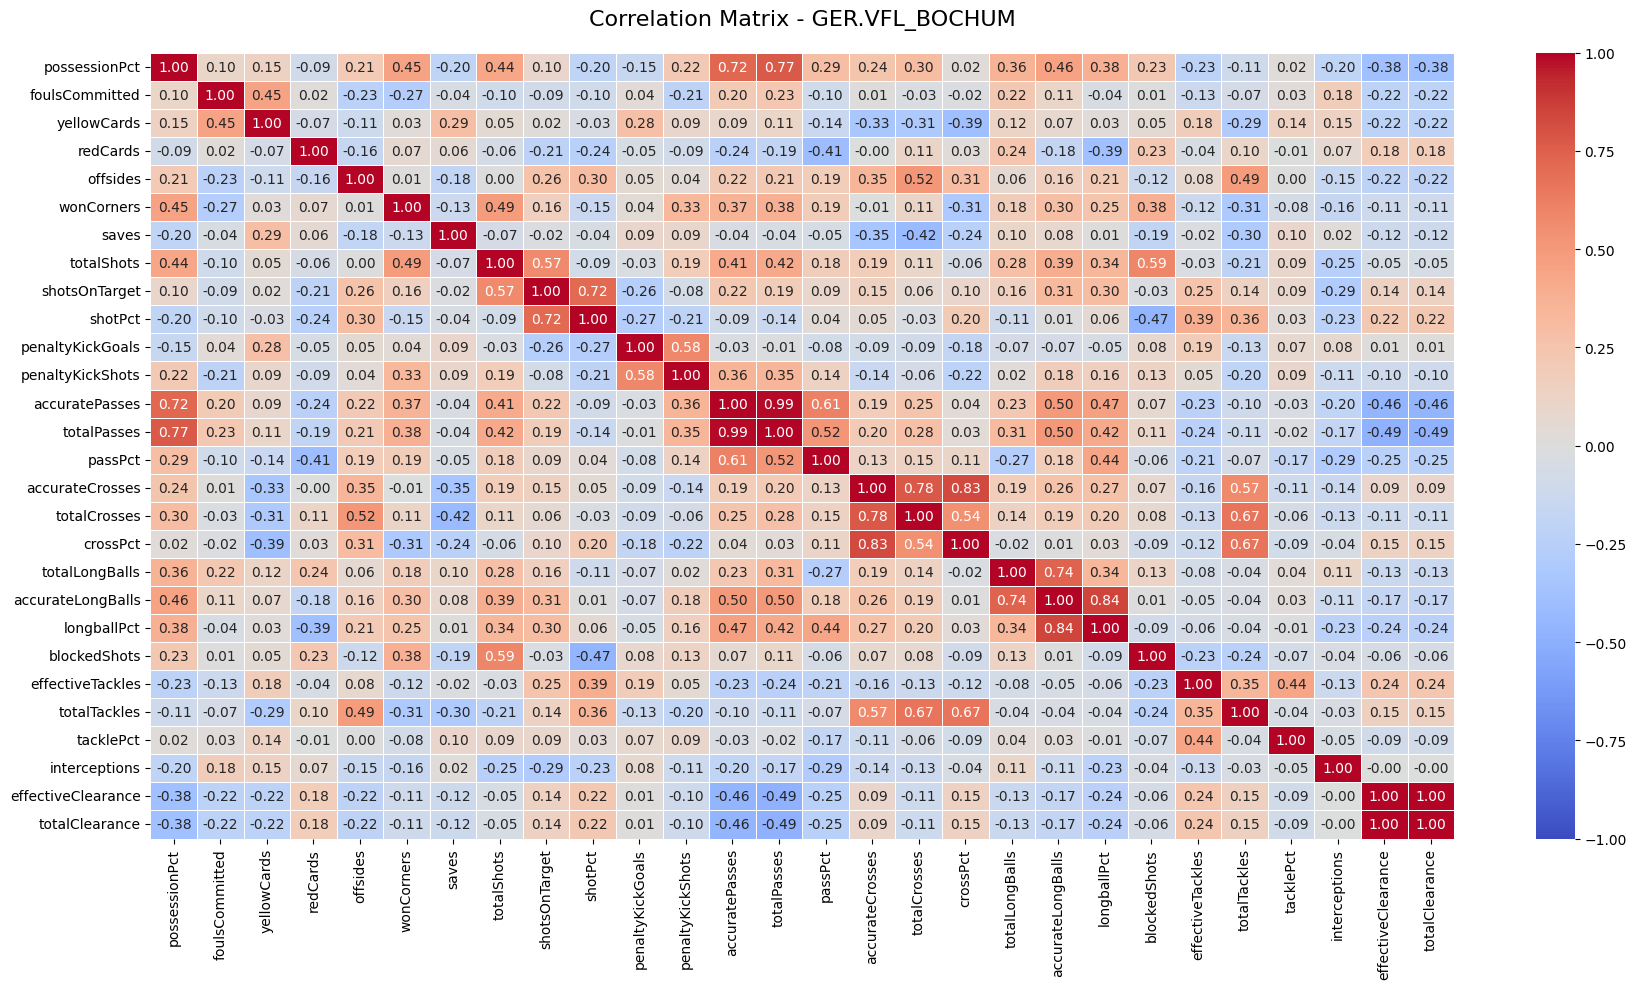

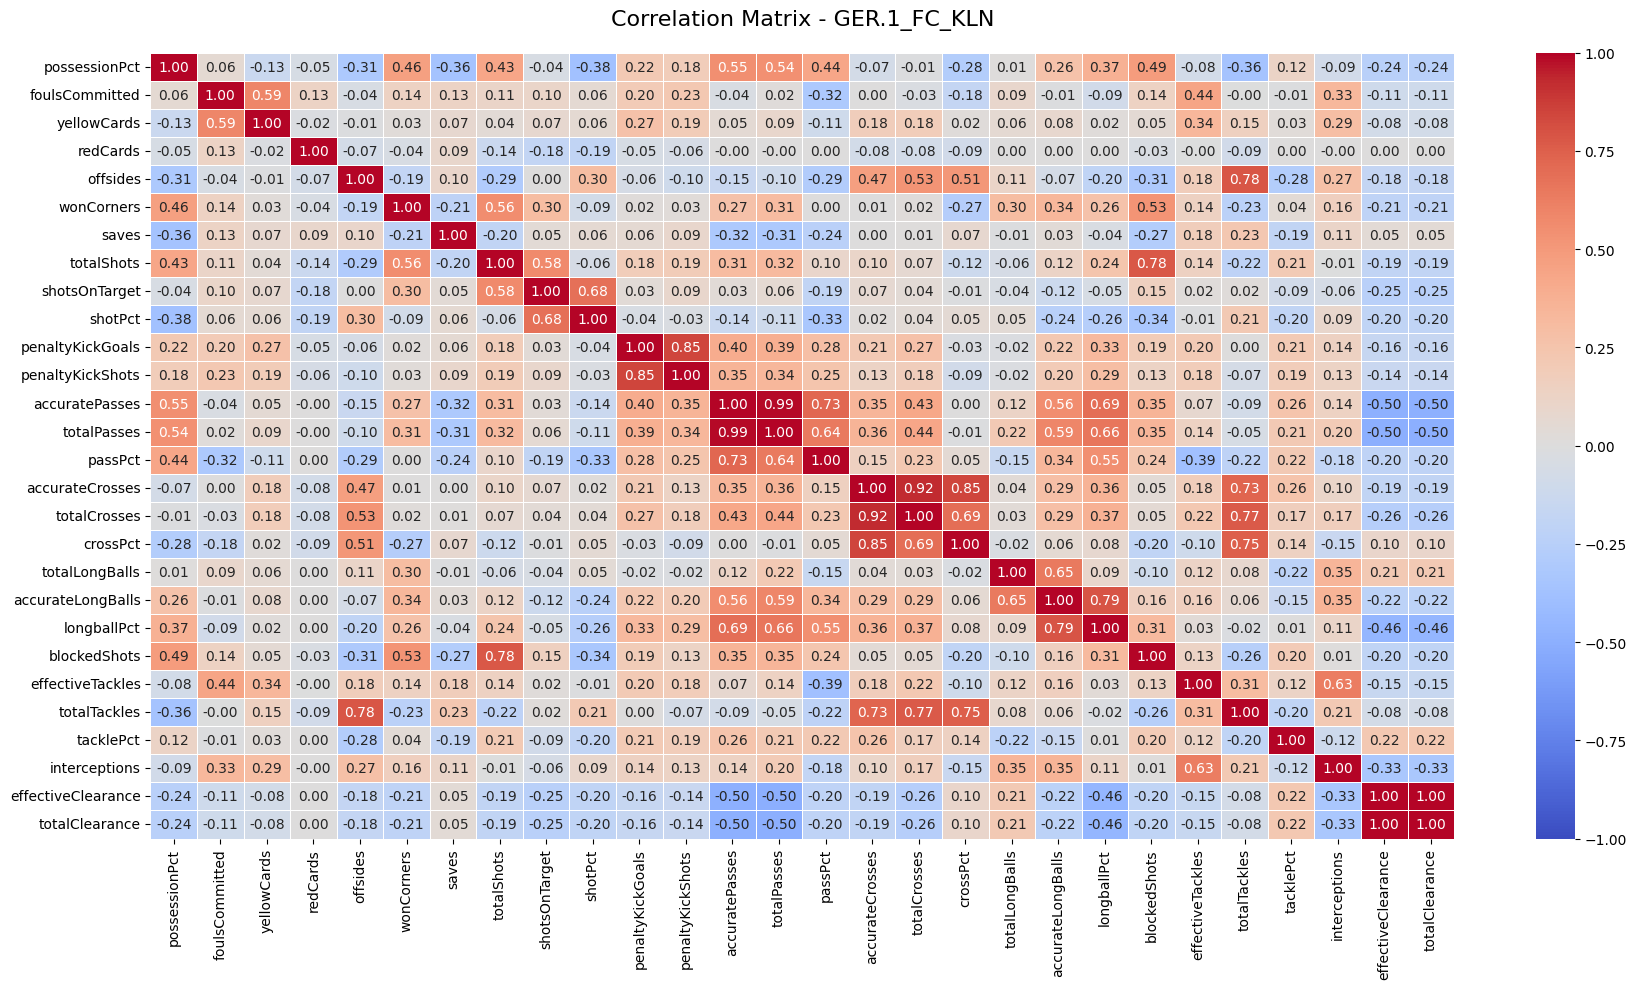

In [29]:
for team in teams:
    matriz_correlacion = equip_no_rep_clean.query(f"slug == '{team}'")[columns].corr()

    plt.figure(figsize=(18, 10))
    sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", 
                linewidths=.5, cbar=True, center=0, vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix - {team.upper()}", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

### ING. ESTADÍSTICAS: CREACIÓN DE KPIs

In [20]:
def crear_features_avanzadas(df):
    """
    Crea features avanzadas de análisis de fútbol.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame con las estadísticas base del equipo
        
    Returns:
    --------
    pd.DataFrame con las nuevas features añadidas
    """
    
    return df.assign(
        #1. PRECISIÓN DE TIRO
        #Mide qué tan bien apuntan los tiros (% que van al arco)
        **{
            'precision_tiro': lambda x: np.where(
                x['totalShots'] > 0,
                x['shotsOnTarget'] / x['totalShots'] * 100,
                0
            )
        },
        
        #2. APROVECHAMIENTO DE POSESIÓN
        #Tiros generados por cada 1% de posesión
        ** {
            'aprovechamiento_posesion': lambda x: np.where(
                x['possessionPct'] > 0,
                x['totalShots'] / x['possessionPct'],
                0
            )
        },
        
        #Versión con tiros al arco (más estricta)
        ** {
            'aprovechamiento_posesion_peligroso': lambda x: np.where(
                x['possessionPct'] > 0,
                x['shotsOnTarget'] / x['possessionPct'],
                0
            )
        },
        # 3. PELIGROSIDAD EN CENTROS
        # Combina precisión de centros con capacidad de remate
        **{
            'peligrosidad_centros': lambda x: np.where(
                x['totalCrosses'] > 0,
                (x['accurateCrosses'] / x['totalCrosses']) * x['shotPct'] / 100,
                0
            )
        },
        
        # Ratio simple de centros precisos
        **{
            'precision_centros': lambda x: np.where(
                x['totalCrosses'] > 0,
                x['accurateCrosses'] / x['totalCrosses'] * 100,
                0
            )
        },
        
        # 4. ÍNDICE DE LIMPIEZA DEFENSIVA
        # % de recuperaciones sin faltas
        **{
            'limpieza_defensiva': lambda x: np.where(
                (x['interceptions'] + x['foulsCommitted']) > 0,
                x['interceptions'] / (x['interceptions'] + x['foulsCommitted']) * 100,
                0
            )
        },
        
        # Versión incluyendo tackles
        **{
            'limpieza_defensiva_completa': lambda x: np.where(
                (x['effectiveTackles'] + x['interceptions'] + x['foulsCommitted']) > 0,
                (x['effectiveTackles'] + x['interceptions']) / 
                (x['effectiveTackles'] + x['interceptions'] + x['foulsCommitted']) * 100,
                0
            )
        },
        
        # 5. EFECTIVIDAD DE DESPEJE
        # % de despejes efectivos
        **{
            'efectividad_despeje': lambda x: np.where(
                x['totalClearance'] > 0,
                x['effectiveClearance'] / x['totalClearance'] * 100,
                0
            )
        },
        # 6. ÍNDICE DE VERTICALIDAD
        # % de pases que son largos (juego directo vs. toque)
        **{
            'indice_verticalidad': lambda x: np.where(
                x['totalPasses'] > 0,
                x['totalLongBalls'] / x['totalPasses'] * 100,
                0
            )
        },
        
        # Verticalidad efectiva (solo balones largos precisos)
        **{
            'verticalidad_efectiva': lambda x: np.where(
                x['totalPasses'] > 0,
                x['accurateLongBalls'] / x['totalPasses'] * 100,
                0
            )
        },
        
        # Precisión en verticalidad
        **{
            'precision_verticalidad': lambda x: np.where(
                x['totalLongBalls'] > 0,
                x['accurateLongBalls'] / x['totalLongBalls'] * 100,
                0
            )
        },
        
        # 7. INTENSIDAD DE CIRCULACIÓN
        # Pases por cada 1% de posesión
        **{
            'intensidad_circulacion': lambda x: np.where(
                x['possessionPct'] > 0,
                x['totalPasses'] / x['possessionPct'],
                0
            )
        },
        
        # Solo pases precisos
        **{
            'intensidad_circulacion_precisa': lambda x: np.where(
                x['possessionPct'] > 0,
                x['accuratePasses'] / x['possessionPct'],
                0
            )
        }
        )

In [22]:
equip_no_rep_clean_kpi = crear_features_avanzadas (equip_no_rep_clean)

In [24]:
equip_no_rep_clean_kpi.to_csv("../DATA/equip_no_rep_clean_kpi.csv", index=False)

In [23]:
calculated_columns = [
    'slug',
    'precision_tiro',
    'aprovechamiento_posesion',
    'aprovechamiento_posesion_peligroso',
    'peligrosidad_centros',
    'precision_centros',
    'limpieza_defensiva',
    'limpieza_defensiva_completa',
    'efectividad_despeje',
    'indice_verticalidad',
    'verticalidad_efectiva',
    'precision_verticalidad',
    'intensidad_circulacion',
    'intensidad_circulacion_precisa'
]
equip_no_rep_clean_kpi[calculated_columns].groupby("slug").agg("mean")

,precision_tiro,aprovechamiento_posesion,aprovechamiento_posesion_peligroso,peligrosidad_centros,precision_centros,limpieza_defensiva,limpieza_defensiva_completa,efectividad_despeje,indice_verticalidad,verticalidad_efectiva,precision_verticalidad,intensidad_circulacion,intensidad_circulacion_precisa
slug,,,,,,,,,,,,,
eng.burnley,33.496263,0.211652,0.073299,0.000792,22.869696,41.128271,60.574632,100.0,12.627414,4.986627,42.014062,8.769626,7.164092
eng.luton,32.424686,0.246226,0.077304,0.000570,17.778401,38.858293,59.001694,100.0,19.411100,7.207108,37.561423,7.016615,5.107689
eng.nottm_forest,35.131218,0.283762,0.098975,0.000784,22.223690,40.882643,62.515757,100.0,13.757678,5.609799,42.448279,8.643193,6.921679
eng.sheff_utd,31.767153,0.261016,0.082820,0.000802,24.743162,41.843262,62.162811,100.0,13.986931,5.615083,41.169016,8.169170,6.520644
esp.almeria,37.772460,0.289739,0.104398,0.000034,0.664437,38.267047,55.430286,100.0,62.833581,32.840269,52.436663,5.231384,4.366512
esp.cadiz,35.406694,0.233972,0.082993,0.000011,0.364299,27.687526,37.769481,100.0,12.068454,6.288172,52.063580,4.741485,4.006112
esp.granada_cf,33.961285,0.245580,0.082118,0.000023,0.623198,31.746681,60.853292,100.0,179.412779,73.058940,40.724908,8.272618,6.589234
fra.clermont_foot,33.133167,0.196653,0.065570,0.000025,0.623886,62.097770,72.393259,100.0,11.407767,5.339806,46.808511,8.387751,7.044082
ger.1_fc_kln,33.002657,0.313713,0.106986,0.000346,9.665468,45.427474,62.414005,100.0,13.863537,6.206844,45.133472,8.873761,7.213404


### DECISIÓN FINAL. FASE 4. PREPARACIÓN Y LIMPIEZA DE DATOS.

1. Se encontró un total de 25 juegos sin registro alguno, los mismo fueron eliminados.
2. Se encontraron valores nulos en variables específicas que (al igual que en los equipos TOP), siguiendo la naturaleza de un partido de futbol, las mismas deberían contar con al menos un valor numérico mayor a cero; bajo esta premisa, se intentó nuevamente imputar el valor de la mediana por variable, sin embargo esto no fue posible debido a que la misma era igualmente cero; este escenario puede deberse a que, la recoleccion de datos en estos equipos de menor relevancia se realiza con menos frecuencia y menor atención a la realidad. Sin embargo para favorecer la obtención de resultados más adaptados a la realidad, se decidió imputar el valor de la media en estas variables sin contar los ceros perjudiciales. 
3. Se encontraron valores átipicos por encima de algunos bigotes, se decidió mantenerlos puesto que aunque son encesarios que salen un poco de lo regular, son posibles y dicen mucho sobre el estilo de juego y nivel de cada equipo. 
Estas acciones dieron paso a un DataFrame limpio y listo para obtener el resto de estudios.

### Diferencias significaticas entre los 10 mejores y los 10 equipos presentados de aqui:

Nota: cuando se mencione los nuevos, se hace referencia a los 10 equipos seleccionados diferente a los 10 mejores.


##### Diferencias significativas con sus matrices de correlación

-Mientras los 10 mejores priorizan (los 1.0 de la matriz) en primer lugar los TotalPasses(Pases Totales) con AccuratePasses(Pases precisos), también viceversa. Estos 10 nuevos lo priorizan en segundo lugar (ya que su item es 0.98).

-Estos 10 nuevos priorizan en segundo lugar (ya que su item es 0.86) los AccurateLongBalls(Balones Largos Precisos) con TotalLongBalls(Balones Largos Totales), también viceversa. Mientras que los 10 mejores lo priorizan más como en tercer lugar(ya que su item es 0.70).

-Los 10 nuevos priorizan en segundo lugar (ya que su item es 0.83) los AccurateCrosses(Centros Precisos) con CrossPct(Porcentaje de centros), también viceversa. Más sin embargo, los 10 mejores suelen priorizar esto más entre 4 y 5 lugar (0.58).

-Los 10 mejores priorizan en tercer lugar (debido ser 0.74 de item) los AccurateCrosses(Centros Precisos) con TotalCrosses(Centros Totales), también viceversa; pero estos 10 nuevos su importancia se encuentra como segunda prioridad en el juego(debido ser 0.86 de item).

-Una diferencia muy clara esta que los 10 mejores toman mucho en cuenta(debido a ser 0.86 y 0.85 de item) son: 

☼PossessionPct(Porcentaje de Posesión) con TotalPasses(Pases Totales), también viceversa.

☼PossessionPct(Porcentaje de Posesión) con AccuratePasses(Pases precisos), también viceversa.

Y estos 10 nuevos a penas lo toman en cuenta (debido a ser 0.40 y 0.44 de item).


Por ende, claramente las estrategias de juego e importancia de los 10 nuevos, tienen una base prácticamente fuera del sentido de la base de los 10 mejores; porque los nuevos se basan en el movimiento rápido del balón (pases largos) y no tanto en la precision de compartir la pelota dentro del equipo, cuando claramente los 10 mejores es su máxima prioridad la precision de compartir la pelota y no tanto la rapidez. Por lo que podemos decir que los 10 nuevos tienen un comportamiento más individual que los 10 mejores.


##### Diferencias significativas con sus KPIs

-La precision de tiro de los 10 mejores están en un margen mas pequeño (entre 37 y 43) que los 10 nuevos (entre 31 y 38).

-Existe una alta diferencia en el intervalo de la precision de centros de los 10 mejores ya que se encuentran entre los 20 y 27 pero los 10 nuevos están entre 0 y 25.

-El margen de limpieza defensiva de los 10 mejores se mantienen estables y pequeños entre un margen de 38 y 47, pero los nuevos son inestables y muy grandes entre 31 y 63.

-El conjunto de limpieza defensiva completa de los 10 mejores se mantienen estables y pequeños entre un rango de 59 y 66, pero los nuevos son inestables y muy grandes entre 37 y 73.

-Tanto el índice de verticalidad como la verticalidad efectiva de los nuevos equipos son inestables y grandes, con índice de 11 a 180 y con efectividad de 4 a 74; pero los 10 mejores equipos son estables y pequeños, con índice de 6 a 10 y con efectividad de 3 a 6.

-Aunque la precision de verticalidad de los 10 mejores con los 10 nuevos son estables el rango de los 10 mejores se encuentran por encima de los nuevos, debido a que los mejores están entre 46 a 64 y los nuevos están entre 37 a 53.

-La intensidad de circulación de los 10 nuevos tienen un mínimo de 4.7 y máximo de 8.87; mientras que los mejores tienen un máximo de 10.3 y mínimo de 8.5.

-Para la intensidad de circulación precisa, ambos equipos mantiene un margen claramente estable pero los mejores se encuentran entre 7 a 10 y los nuevos entre 4 a 8.

-Aunque la mayoría de la peligrosidad de centros los nuevos se encuentran aproximadamente entre 0.001 existen 5 equipos que no lo logran, mientras que todos los 10 mejores si se aproximan o son 0.001.


Por lo que, podemos decir que la clave de los 10 mejores equipos durante el juego, se encuentran en la precisión de tiros, la precisión de centros, la limpieza defensiva, la limpieza defensiva completa, el índice de verticalidad, la verticalidad efectiva, la precisión de verticalidad, la intensidad de circulación, la intensidad de circulación precisa y la peligrosidad de centros.
